In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# Mixed precision: float16 compute + float32 weights → uses CUDA Tensor Cores
tf.keras.mixed_precision.set_global_policy('mixed_float16')

I0000 00:00:1781263808.690996  400433 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781263808.723997  400433 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781263809.608980  400433 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [3]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

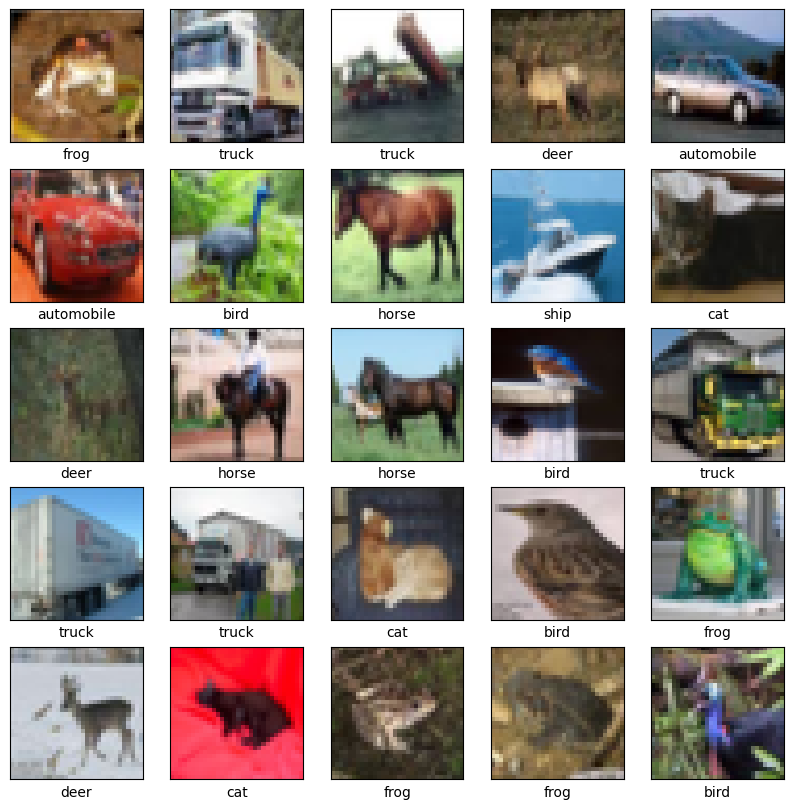

In [4]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [5]:
inputs = layers.Input(shape=(32, 32, 3))

x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomTranslation(0.1, 0.1, fill_mode="reflect")(x)

# Stem
x = layers.Conv2D(16, 3, padding='same', use_bias=False)(x)

# Residual block (pre-activation / v2 style)
def block(x, filters, stride=1):
    shortcut = x

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, use_bias=False)(shortcut)

    x = layers.Add()([x, shortcut])
    return x

# Stages
x = block(x, 16, stride=1)
x = block(x, 16, stride=2)

x = block(x, 32, stride=1)
x = block(x, 32, stride=2)

x = block(x, 64, stride=1)

# Head
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.Dropout(0.1)(x)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(10, dtype='float32')(x)  # float32 required for mixed precision stability

model = models.Model(inputs, outputs)
model.summary()

I0000 00:00:1781263812.601255  400433 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6153 MB memory:  -> device: 0, name: NVIDIA RTX 2000 Ada Generation Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 32, 32, 3) │          0 │ input_layer[0][0] │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation  │ (None, 32, 32, 3) │          0 │ random_flip[0][0] │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        432 │ random_translati… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      2,304 │ re_lu[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │      2,304 │ re_lu_1[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ conv2d_2[0][0],   │
│                     │ 16)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ add[0][0]         │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │      2,304 │ re_lu_2[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │      2,304 │ re_lu_3[0][0]   

 Total params: 103,034 (402.48 KB)

 Trainable params: 102,362 (399.85 KB)

 Non-trainable params: 672 (2.62 KB)

In [6]:
BATCH_SIZE = 256
EPOCHS = 500
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_images, train_labels))
    .cache()
    .shuffle(50000, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((test_images, test_labels))
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

steps_per_epoch = 50000 // BATCH_SIZE
total_steps = steps_per_epoch * EPOCHS

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.1,
    decay_steps=total_steps
)

optimizer = tf.keras.optimizers.SGD(
    learning_rate=lr_schedule,
    momentum=0.9,
    nesterov=True
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds)

Epoch 1/500


E0000 00:00:1781263816.909144  400433 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1781263817.594667  400602 cuda_dnn.cc:461] Loaded cuDNN version 92301


195/195 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.4370 - loss: 1.5232 - val_accuracy: 0.2641 - val_loss: 2.9469
Epoch 2/500
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6047 - loss: 1.0962 - val_accuracy: 0.5392 - val_loss: 1.5029
Epoch 3/500
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6726 - loss: 0.9159 - val_accuracy: 0.3942 - val_loss: 2.9506
Epoch 4/500
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7159 - loss: 0.8082 - val_accuracy: 0.6329 - val_loss: 1.1392
Epoch 5/500
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7440 - loss: 0.7334 - val_accuracy: 0.6190 - val_loss: 1.2618
Epoch 6/500
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7610 - loss: 0.6834 - val_accuracy: 0.6451 - val_loss: 1.1923
Epoch 7/500
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7731 - loss: 0.6512 - val_accuracy: 0.7261 - val_loss: 0.8073
Epoch 8/500
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7890 - loss: 0.6150 - val_accurac

In [7]:
test_loss = model.evaluate(test_images,  test_labels, verbose=2)

313/313 - 1s - 5ms/step - accuracy: 0.8914 - loss: 0.4506


In [8]:
test_loss

[0.45061635971069336, 0.8913999795913696]

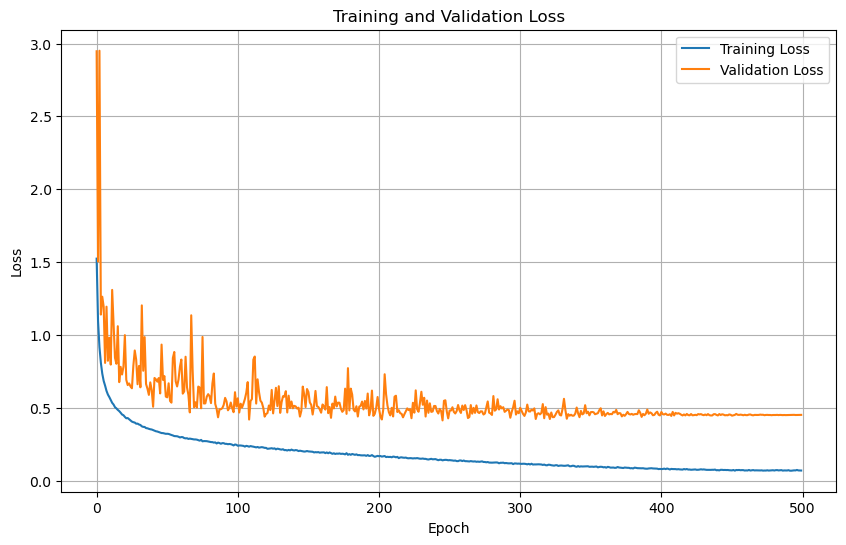

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Please add confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
predictions = model.predict(test_images)
predictions = np.argmax(predictions, axis=1)
